###  In this  problem we will train a model to predict the percentage of marks that a student is expected to score based upon the number of hours they studied. We will assume that the relationship between the expected score (label) and the numer of hours studied (features) is linear.

Thus we are dealing with a simple linear regression task because of the linearity assumption and having just one feature.

### Linear Regression

</span>
Linear Regression is a supervised Machine Learning model in which the model finds the best (linear) line that best describes the relationship between the features and a continuous/real-valued response (label) variable.




In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets
%matplotlib inline

In [2]:
df = pd.read_csv('student_scores-1.csv')
df.shape

(25, 2)

In [3]:
df.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [4]:
df.describe()

,Hours,Scores
count,25.000000,25.000000
mean,5.012000,51.480000
std,2.525094,25.286887
min,1.100000,17.000000
25%,2.700000,30.000000
50%,4.800000,47.000000
75%,7.400000,75.000000
max,9.200000,95.000000


## Describe function
- **count** - Count all non-null numbers group by each column.
- **mean** - Return the mean of values over request axis.
- **std** - Return the standard deviation over requested axis. Standard deviation tells how spread out numbers are in datasets from average (mean).
- **min** - Minimum of the values from dataset.
- **max** - Maximum of the values from dataset.
- **25%** - First quartile (Q1) - 25% of the values are below this number.
- **50%** - Second quartile (Q2) - 50% of the values are below this number.
- **75%** - Third quartile (Q3) - 75% of the values are below this number.

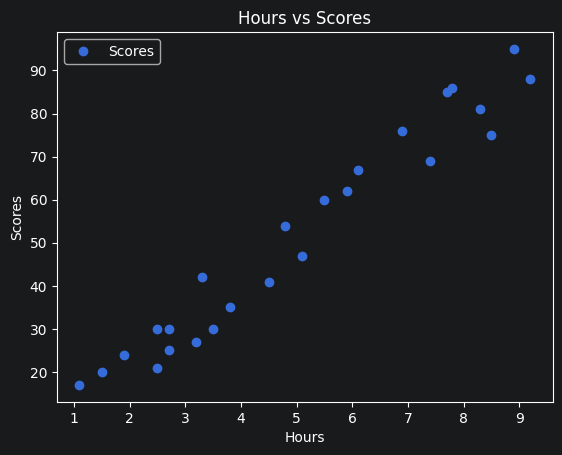

In [6]:
df.plot(x='Hours', y='Scores', style='o')
plt.title('Hours vs Scores')
plt.xlabel('Hours')
plt.ylabel('Scores')
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
X = df.iloc[:, :-1].values
y = df.iloc[:, 1].values

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [10]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9.91]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.018
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[11.12]


In [11]:
print(regression.coef_, regression.intercept_)

[9.91065648] 2.0181600414346903


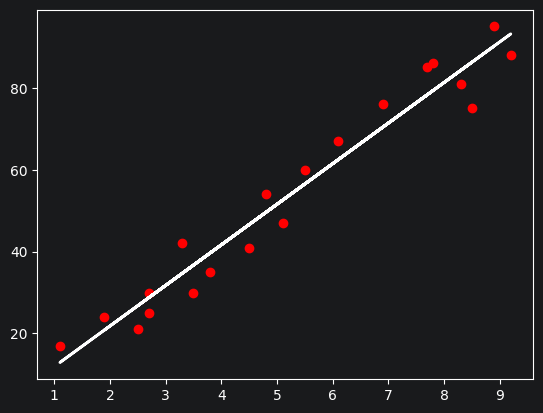

In [15]:
y_pred = regression.predict(X_train)
plt.scatter(X_train, y_train, color='red')
plt.plot(X_train, y_pred, color='white', linewidth=2)
plt.show()

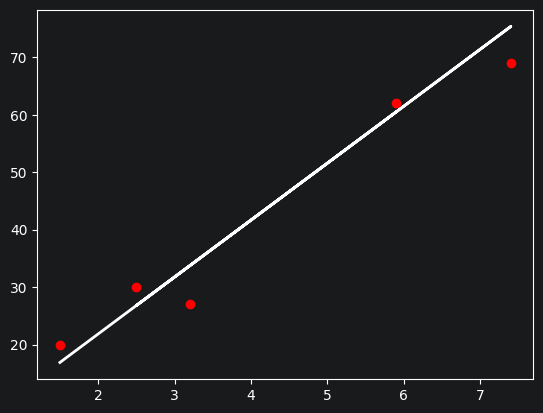

In [18]:
y_test_pred = regression.predict(X_test)
plt.scatter(X_test, y_test, color='red')
plt.plot(X_test, y_test_pred, color='white', linewidth=2)
plt.show()

In [19]:
test_by_pred_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_test_pred})
test_by_pred_df.head()

,Actual,Predicted
0,20,16.884145
1,27,33.732261
2,69,75.357018
3,30,26.794801
4,62,60.491033


In [22]:
from sklearn import metrics
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_test_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_test_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)))

Mean Absolute Error: 4.1838598990029725
Mean Squared Error: 21.59876930721736
Root Mean Squared Error: 4.647447612100362


## Encoding Categorical Data
Categorical data encoding means converting categorical data to number. There are two types of approaches,

- Ordinal Encoding
- One-Hot Encoding

## Ordinal Encoding
In ordinal encoding, each unique category value is assigned by and integer value.

For example, "red" is 1, "green" is 2 and "blue" is 3.

This is called ordinal encoding or integer encoding and it is easily reversible.

In [24]:
from numpy import asarray
data = asarray([['red'], ['blue'], ['green'], ['white'], ['black']])
print(data)

[['red']
 ['blue']
 ['green']
 ['white']
 ['black']]


In [26]:
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
result = encoder.fit_transform(data)
result

array([[3.],
       [1.],
       [2.],
       [4.],
       [0.]])

In [29]:
encoder.categories_

[array(['black', 'blue', 'green', 'red', 'white'], dtype='<U5')]

In [30]:
original_data = encoder.inverse_transform(result)
original_data

array([['red'],
       ['blue'],
       ['green'],
       ['white'],
       ['black']], dtype='<U5')

## One-Hot Encoding
One-hot encoding is way to convert categorical values to numeric data so it can input to machine learning algorithm. This is called one-hot because only one of the value in vactor is hot (means have 1 value) while rest are 0.

For example for "red" the vector will be [1, 0, 0] and for "green" will be [0, 1, 0] and so on.

In [39]:
employees = asarray([['red'], ['green'], ['blue'], ['white']])
employees

array([['red'],
       ['green'],
       ['blue'],
       ['white']], dtype='<U5')

In [42]:
from sklearn.preprocessing import OneHotEncoder
oneHotEncoder = OneHotEncoder(sparse_output=False)
oneHotEncoded = oneHotEncoder.fit_transform(employees)
print(oneHotEncoded)

[[0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]]


### Example:
we will create a small dataset with two features having different ranges, and scale them using the normalization technique.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
df = pd.DataFrame({'WEIGHT': [15, 18, 12, 10], 'PRICE': [1, 3, 2, 5]}, index=['Orange', 'Apple', 'Mango', 'Pineapple'])
print(df)

           WEIGHT  PRICE
Orange         15      1
Apple          18      3
Mango          12      2
Pineapple      10      5


In [45]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
min_max_scaled_data = scaler.fit_transform(df)
df_from_transformed_data = pd.DataFrame(min_max_scaled_data, columns=['WEIGHT', 'PRICE'], index=['Orange', 'Apple', 'Mango', 'Pineapple'])
print(df_from_transformed_data)

           WEIGHT  PRICE
Orange      0.625   0.00
Apple       1.000   0.50
Mango       0.250   0.25
Pineapple   0.000   1.00


### Data scaling technique: Data Standardization

Standardizing a dataset involves rescaling the distribution of values so that the mean of observed values is 0 and the standard deviation is 1. It is sometimes referred to as “whitening.”

This can be thought of as subtracting the mean value or centering the data.

Like normalization, standardization can be useful, and even required in some machine learning algorithms when your data has input values with differing scales.

Standardization assumes that your observations fit a Gaussian distribution (bell curve) with a well-behaved mean and standard deviation. You can still standardize your data if this expectation is not met, but you may not get reliable results.

Standardization requires that you know or are able to accurately estimate the mean and standard deviation of observable values. You may be able to estimate these values from your training data.

The formula is:

$y = \frac{(x - mean)} {standard\_deviation}$

where:
- $mean = \frac{sum(x)}{count(x)}$
- $standard\_deviation = \sqrt{\frac{\sum (x - mean)^2}{count(x)}}$

In [46]:
from sklearn.preprocessing import StandardScaler
standardScaler = StandardScaler()
scaled_df = standardScaler.fit_transform(df)
df2 = pd.DataFrame(scaled_df, columns=['WEIGHT', 'PRICE'], index=['Orange', 'Apple', 'Mango', 'Pineapple'])
print(df2)

             WEIGHT     PRICE
Orange     0.412393 -1.183216
Apple      1.402136  0.169031
Mango     -0.577350 -0.507093
Pineapple -1.237179  1.521278


#### Data standardization vs normalization, which one to use?


Standardization is useful when the data follows a normal distribution or when the scale of the variables is not important.

In general, standardization is a more widely used technique, but normalization may be preferred in some cases, such as when the data follows a skewed distribution or when the values of the variables have a specific range. It is always a good idea to explore both techniques and choose the one that works best for your data and machine learning algorithm.

## Normalisation vs Standardization
- **Normalisation** will be used when data is not evenly distributed - (have outliers).
- **Standardization** will be used when data is evenly distributed.

In [47]:
import numpy as np
import numpy.random as rnd
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

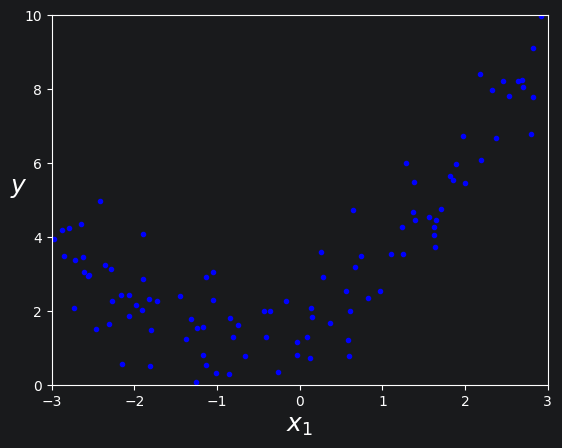

In [48]:
plt.plot(X, y, "b.")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([-3, 3, 0, 10])
plt.show()

In [50]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
X_poly

array([[-7.52759287e-01,  5.66646544e-01],
       [ 2.70428584e+00,  7.31316190e+00],
       [ 1.39196365e+00,  1.93756281e+00],
       [ 5.91950905e-01,  3.50405874e-01],
       [-2.06388816e+00,  4.25963433e+00],
       [-2.06403288e+00,  4.26023172e+00],
       [-2.65149833e+00,  7.03044338e+00],
       [ 2.19705687e+00,  4.82705891e+00],
       [ 6.06690070e-01,  3.68072842e-01],
       [ 1.24843547e+00,  1.55859111e+00],
       [-2.87649303e+00,  8.27421218e+00],
       [ 2.81945911e+00,  7.94934969e+00],
       [ 1.99465584e+00,  3.97865194e+00],
       [-1.72596534e+00,  2.97895634e+00],
       [-1.90905020e+00,  3.64447265e+00],
       [-1.89957294e+00,  3.60837736e+00],
       [-1.17454654e+00,  1.37955958e+00],
       [ 1.48538590e-01,  2.20637127e-02],
       [-4.08329888e-01,  1.66733298e-01],
       [-1.25262516e+00,  1.56906979e+00],
       [ 6.71117368e-01,  4.50398522e-01],
       [-2.16303684e+00,  4.67872835e+00],
       [-1.24713211e+00,  1.55533850e+00],
       [-8.

In [51]:
regression = LinearRegression()
regression.fit(X_poly, y)
print(regression.coef_, regression.intercept_)

[[0.93366893 0.56456263]] [1.78134581]


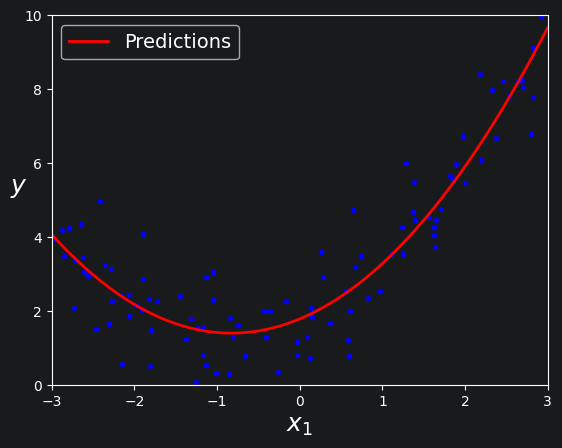

In [53]:
X_new=np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = regression.predict(X_new_poly)
plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.legend(loc="upper left", fontsize=14)
plt.axis([-3, 3, 0, 10])
plt.show()